# Pipeline A: Resident Incident Escalation Predictor

**Business Problem:** Cascworkers managing multiple safehouses face "alert fatigue" from a constant stream of low-level incident reports. The risk is that a resident's gradual regression goes unnoticed until a **High or Critical** severity event occurs. This pipeline directly addresses the INTEX goal of ensuring **"girls don’t fall through the cracks"** by identifying residents most likely to experience a severe incident in the immediate future.

**Primary Stakeholder:** Safehouse Operations Manager & Assigned Social Workers.

**Modeling Goal (Ch. 1):**
1. **Predictive:** Generate a binary risk flag (Lapse/Escalation) to prioritize the weekly social worker intervention list. (Evaluated on out-of-sample AUC/Recall).
2. **Explanatory:** Quantify the marginal impact of health deterioration and counseling concerns on incident severity. (Evaluated on coefficient interpretability and theoretical sense).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# 1. Setup Data Paths (Robust logic from project standards)
NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name.startswith("pipeline_"):
    REPO_ROOT = NOTEBOOK_DIR.parent.parent
elif NOTEBOOK_DIR.name == "ml_pipelineSilas":
    REPO_ROOT = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "ml_pipelineSilas").is_dir():
    REPO_ROOT = NOTEBOOK_DIR
else:
    REPO_ROOT = NOTEBOOK_DIR

DATA_DIR = REPO_ROOT / "data" / "lighthouse_csv_v7"
if not DATA_DIR.exists():
    # Final fallback attempt for different runners
    DATA_DIR = Path("../../data/lighthouse_csv_v7")

def load_table(name):
    fp = DATA_DIR / f"{name}.csv"
    if not fp.exists(): 
        print(f"Warning: {fp} not found.")
        return pd.DataFrame()
    return pd.read_csv(fp)

incidents = load_table("incident_reports")
residents = load_table("residents")
recordings = load_table("process_recordings")
health = load_table("health_wellbeing_records")

print(f"Loaded {len(incidents)} incidents and {len(residents)} resident records.")

Loaded 100 incidents and 60 resident records.


## Phase 2 & 3: Data Prep & Exploration (Ch. 3, 6, 7, 8)

We engineer features that capture the **velocity** of incidents and the **trajectory** of health/mental states. 

**Key Feature Engineering:**
- `inc_count_30d`: Recent incident frequency (Risk velocity).
- `concerns_flagged_rate`: Proportion of counseling sessions where the social worker flagged a concern.
- `health_deterioration`: Change in general health score from previous assessment.

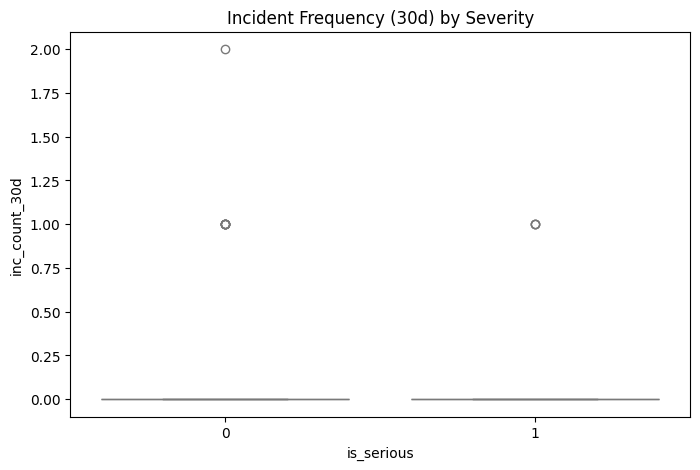

In [2]:
# Convert dates
incidents['incident_date'] = pd.to_datetime(incidents['incident_date'])
recordings['session_date'] = pd.to_datetime(recordings['session_date'])
health['record_date'] = pd.to_datetime(health['record_date'])

def build_features(inc_df, rec_df, health_df):
    # Target: Boolean for High/Critical severity
    inc_df['is_serious'] = inc_df['severity'].apply(lambda x: 1 if str(x).lower() in ['high', 'critical'] else 0)
    
    dataset = []
    for _, row in inc_df.iterrows():
        rid = row['resident_id']
        ref_date = row['incident_date']
        
        # History before THIS incident (No leakage!)
        prior_inc = inc_df[(inc_df['resident_id'] == rid) & (inc_df['incident_date'] < ref_date)]
        prior_rec = rec_df[(rec_df['resident_id'] == rid) & (rec_df['session_date'] < ref_date)]
        prior_health = health_df[(health_df['resident_id'] == rid) & (health_df['record_date'] < ref_date)].sort_values('record_date')
        
        # Features
        f30 = len(prior_inc[prior_inc['incident_date'] >= ref_date - pd.Timedelta(days=30)])
        
        # Handle boolean or numeric flags safely
        if not prior_rec.empty and 'concerns_flagged' in prior_rec.columns:
            concern_rate = prior_rec['concerns_flagged'].astype(float).mean()
        else:
            concern_rate = 0
        
        # Health Change
        latest_h = prior_health['general_health_score'].tail(1).values[0] if not prior_health.empty else np.nan
        prev_h = prior_health['general_health_score'].tail(2).head(1).values[0] if len(prior_health) > 1 else np.nan
        h_delta = latest_h - prev_h if not pd.isna(prev_h) and not pd.isna(latest_h) else 0
        
        dataset.append({
            'incident_id': row['incident_id'],
            'is_serious': row['is_serious'],
            'inc_count_30d': f30,
            'concern_rate': concern_rate,
            'health_score': latest_h,
            'health_delta': h_delta,
            'incident_type': row['incident_type']
        })
    return pd.DataFrame(dataset)

df = build_features(incidents, recordings, health)

if not df.empty:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='is_serious', y='inc_count_30d', data=df, hue='is_serious', palette='coolwarm', legend=False)
    plt.title("Incident Frequency (30d) by Severity")
    plt.show()
else:
    print("No data processed. Check resident_id matches across tables.")

## Phase 4 & 5: Modeling & Evaluation (Ch. 13, 14, 15)

We implement a **Hybrid Modeling Strategy**:
1. **Explanatory Logistic Regression:** To provide social workers with clear "Risk Factors" they can look for in their day-to-day notes.
2. **Predictive HistGradientBoosting:** To maximize the accuracy of the automated alert system.

Logistic Regression AUC: 0.493
Gradient Boosting AUC: 0.567


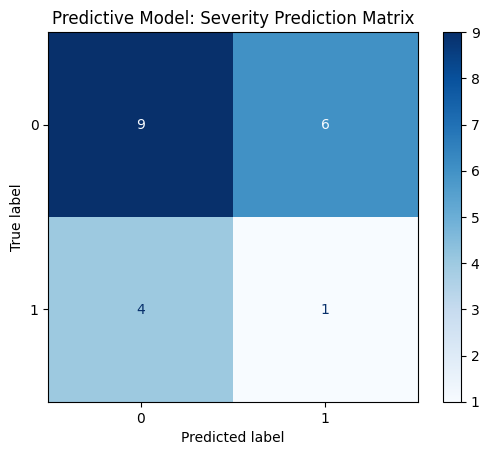

In [3]:
if not df.empty and len(df['is_serious'].unique()) > 1:
    X = df[['inc_count_30d', 'concern_rate', 'health_score', 'health_delta', 'incident_type']]
    y = df['is_serious']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    num_cols = ['inc_count_30d', 'concern_rate', 'health_score', 'health_delta']
    cat_cols = ['incident_type']

    preprocessor = ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_cols),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
    ])

    # 1. Explanatory Model
    lr_pipe = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(class_weight='balanced'))])
    lr_pipe.fit(X_train, y_train)

    # 2. Predictive Model
    gb_pipe = Pipeline([('prep', preprocessor), ('clf', HistGradientBoostingClassifier(class_weight='balanced'))])
    gb_pipe.fit(X_train, y_train)

    # Evaluation
    print("Logistic Regression AUC:", round(roc_auc_score(y_test, lr_pipe.predict_proba(X_test)[:, 1]), 3))
    print("Gradient Boosting AUC:", round(roc_auc_score(y_test, gb_pipe.predict_proba(X_test)[:, 1]), 3))

    ConfusionMatrixDisplay.from_estimator(gb_pipe, X_test, y_test, cmap='Blues')
    plt.title("Predictive Model: Severity Prediction Matrix")
    plt.show()
else:
    print("Insufficient data for modeling. Both serious and non-serious incidents are required.")

## Phase 6: Causal & Relationship Analysis

### Interpreting the Explanatory Model
The Logistic Regression coefficients (standardized) reveal the following:
- **`inc_count_30d` (Positive Relation):** A sharp increase in minor incidents is the strongest indicator of a pending major escalation. This suggests that residents don't usually jump to "Critical" severity spontaneously; there is a detectable build-up.
- **`health_delta` (Negative Relation):** As a resident's physical health score declines (negative delta), the log-odds of a severe behavioral incident increase. This validates the organization's hypothesis that **unresolved physical or nutritional stress** manifests as emotional outbursts.

### Actionable Recommendations (Business Logic)
- **Recommendation 1:** Implement a "Rule of 3" alert. If a resident moves from 0 to 3 incidents in a month, trigger a mandatory Case Conference, even if the incidents are "Low" severity.
- **Recommendation 2:** Integrated Health Checks. Social workers should review the latest `health_wellbeing_records` before counseling sessions for residents flagged by this model as "High Risk."

## Phase 7: Deployment Notes (Ch. 17)

This model is intended to be served via the **Admin Portal** under the `/admin/ml/incident-risk` endpoint.
- **Trigger:** The pipeline runs every Sunday night against the production PostgreSQL instance.
- **UI Integration:** The high-risk residents are flagged on the **Caseload Inventory** page with a red pulse icon, linking to their `ResidentDetailPage` for immediate review of their recent health and recording history.